In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl
from torch.distributions import Bernoulli
import xarray as xr
import xrft
import numpy as np
import matplotlib.pyplot as plt
import src.data
from scipy.stats import multivariate_normal
import pandas as pd
import functools as ft
from collections import namedtuple
from IPython.display import Markdown, display
from omegaconf import OmegaConf
import yaml
import inspect
import hydra
import os
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.colors as colors
from matplotlib.colors import LogNorm 
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from PIL import Image
import kornia.filters as kfilts
from torch.amp import autocast, GradScaler
from scipy.ndimage import gaussian_filter
from scipy.ndimage import binary_dilation
from skimage.morphology import disk, dilation
from sklearn.linear_model import LinearRegression

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#device = "cpu"

/Odyssey/private/ochapron/miniconda/miniconda3/envs/fdv/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


ModuleNotFoundError: No module named 'skimage'

# Utils Functions

In [ ]:
def plot_tensor(tensor, title = 'Logits Plot'):
    pos_tensor_numpy = tensor.numpy()
    plt.imshow(pos_tensor_numpy, cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.show()

def rmse_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    #mask = ~np.isnan(ds['input'])
    try:
        return rmse_based_scores(ds[ref_variable], ds[study_variable])[2:]
    except:
        return [np.nan, np.nan]

def psd_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    print(ds)
    try:
        return psd_based_scores(ds[ref_variable], ds[study_variable])[1:]
    except:
        return [np.nan, np.nan]

def rmse_based_scores_lead(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )

def rmse_based_scores_day(da_rec, da_ref):
    # Calculate leaderboard RMSE
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return np.round(leaderboard_rmse.values, 5).item()

def rmse_based_scores(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        rmse_t,
        rmse_xy,
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )


def psd_based_scores(da_rec, da_ref):
    print('hello')
    err = da_rec - da_ref
    err["time"] = (err.time - err.time[0]) / np.timedelta64(1, "D")
    signal = da_ref
    signal["time"] = (signal.time - signal.time[0]) / np.timedelta64(1, "D")
    psd_err = xrft.power_spectrum(
        err, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()
    psd_signal = xrft.power_spectrum(
        signal, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()

    mean_psd_signal = psd_signal.mean(dim="lat").where(
        (psd_signal.freq_lon > 0.0) & (psd_signal.freq_time > 0), drop=True
    )
    
    mean_psd_err = psd_err.mean(dim="lat").where(
        (psd_err.freq_lon > 0.0) & (psd_err.freq_time > 0), drop=True
    )
    print(mean_psd_err)
    psd_based_score = 1.0 - mean_psd_err / mean_psd_signal
    level = [0.5]
    cs = plt.contour(
        1.0 / psd_based_score.freq_lon.values,
        1.0 / psd_based_score.freq_time.values,
        psd_based_score,
        level,
    )
    x05, y05 = cs.collections[0].get_paths()[0].vertices.T
    plt.close()

    shortest_spatial_wavelength_resolved = np.min(x05)
    shortest_temporal_wavelength_resolved = np.min(y05)
    psd_da = 1.0 - mean_psd_err / mean_psd_signal
    psd_da.name = "psd_score"
    return (
        psd_da.to_dataset(),
        np.round(shortest_spatial_wavelength_resolved, 3).item(),
        np.round(shortest_temporal_wavelength_resolved, 3).item(),
    )

def weighted_mse(err, weight = None):
    if weight is None:
        err_w = err
        non_zeros = (torch.ones_like(err) == 0.0)
    else:
        err_w = err * weight[None, ...]
        non_zeros = (torch.ones_like(err) * weight[None, ...]) == 0.0
    err_num = err.isfinite() & ~non_zeros
    if err_num.sum() == 0:
        return torch.scalar_tensor(1000.0, device=err_num.device).requires_grad_()
    loss = F.mse_loss(err_w[err_num], torch.zeros_like(err_w[err_num]))
    return loss

def pprint_cfg(cfg):
    display(Markdown("""```yaml\n\n""" +yaml.dump(OmegaConf.to_container(cfg), default_flow_style=None, indent=2)+"""\n\n```"""))


def update_dz_fig(frame, da, da_4dVN):
    plt.clf()  # Clear the previous frame
    global_min = np.min([da[frame, :, :], da_4dVN[frame, :, :]])
    global_max = np.max([da[frame, :, :], da_4dVN[frame, :, :]])
    
    mu_4dVN = rmse_based_scores_day(da[frame, :, :], da_4dVN[frame, :, :])

    corr_da_4dVN = xr.corr(da[frame, :, :], da_4dVN[frame, :, :])

    # Ground truth
    ax0 = fig.add_subplot(gs[0])
    im0 = ax0.imshow(da[frame, :, :] + 1, extent=[-60, -54, 32, 38], cmap='viridis', vmin=global_min, vmax=global_max)
    ax0.text(0.5, 1.05, 'Ground truth', ha='center', va='bottom', transform=ax0.transAxes, fontsize=14)

    title_4dVarNet = '4dVarNet'
    subtitle_4dVarNet = f'Correlation: {corr_da_4dVN:.2f}\nRMSE Score: {mu_4dVN:.2f}'

    # 4dVarNet
    ax2 = fig.add_subplot(gs[1])
    im2 = ax2.imshow(da_4dVN[frame, :, :] + 1, extent=[-60, -54, 32, 38], cmap='viridis', vmin=global_min, vmax=global_max)
    ax2.text(0.5, 1.1, title_4dVarNet, ha='center', va='bottom', transform=ax2.transAxes, fontsize=14)
    ax2.text(0.5, 1.01, subtitle_4dVarNet, ha='center', va='bottom', transform=ax2.transAxes, fontsize=10, linespacing=1.5)

    # Colorbar
    ax3 = fig.add_subplot(gs[2])
    plt.colorbar(im2, cax=ax3, label='ECS')

    ax3_position = ax3.get_position()
    new_position = [ax3_position.x0 - 0.03, ax3_position.y0, ax3_position.width, ax3_position.height]
    ax3.set_position(new_position)

# Field Selection

In [ ]:
tgt_ds = xr.open_dataset('/Odyssey/public/natl60/ssh/NATL60-CJM165-ssh-2012-2013-1_20.nc')
tgt_ds

<xarray.Dataset> Size: 11GB
Dimensions:       (lat: 780, lon: 1640, time: 365)
Coordinates:
  * lat           (lat) float64 6kB 27.05 27.1 27.15 27.2 ... 65.9 65.95 66.0
  * lon           (lon) float64 13kB -76.95 -76.9 -76.85 -76.8 ... 4.9 4.95 5.0
  * time          (time) datetime64[ns] 3kB 2012-10-01 2012-10-02 ... 2013-09-30
Data variables:
    mdt           (lat, lon) float64 10MB ...
    sla           (time, lat, lon) float64 4GB ...
    ssh           (time, lat, lon) float64 4GB ...
    ssh_norm      (time, lat, lon) float64 4GB ...
    ssh_variance  (lat, lon) float64 10MB ...
Attributes:
    About:    Created by SOSIE interpolation environement => https://github.c...
    Info:     Horizontal grid read in regulargrid_NATL60.nc / Source field re...

['2009-11-08T00:00:00.000000000000000', '2009-11-09T00:00:00.000000000000000', '2009-11-10T00:00:00.000000000000000', '2009-11-11T00:00:00.000000000000000', '2009-11-12T00:00:00.000000000000000', '2009-11-13T00:00:00.000000000000000', '2009-11-14T00:00:00.000000000000000', '2009-11-15T00:00:00.000000000000000', '2009-11-16T00:00:00.000000000000000', '2009-11-17T00:00:00.000000000000000']


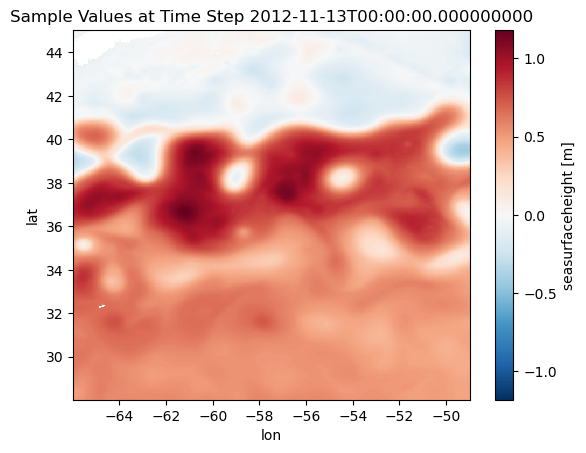

In [ ]:
import pandas as pd

tgt_ds_enatl = xr.open_dataset('/Odyssey/public/enatl60/ssh/eNATL60-BLB002-ssh-2009-2010-1_20.nc')
tgt_ds_natl = xr.open_dataset('/Odyssey/public/natl60/ssh/NATL60-CJM165-ssh-2012-2013-1_20.nc')
time_step_ssh = '2012-11-13T00:00:00.000000000'
time_step_enatl = '2009-11-13T00:00:00.000000000'
time_step_ecs = '2012-11-13T12:00:00.000000000'
inp_da = tgt_ds_natl.ssh.sel(time=time_step_ssh)

# Generate 10 dates centered around 2009-11-13
center_date = pd.Timestamp('2009-11-13')
date_range = pd.date_range(center_date - pd.Timedelta(days=5), periods=10, freq='D')
date_strings = date_range.strftime('%Y-%m-%dT%H:%M:%S.%f000000000').tolist()

enatl = tgt_ds_enatl.ssh.sel(time=date_strings)
warped_field = enatl.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))
inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))
inp_da_GS.fillna(0.0)
warped_field.fillna(0.0)

print(date_strings)
border_size = 50

lat_shape = len(inp_da_GS.lat)
lon_shape = len(inp_da_GS.lon)


crop_lat_start =  border_size
crop_lat_end = lat_shape -  border_size
crop_lon_start =  border_size
crop_lon_end = lon_shape -  border_size


inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))
warped_field_crop = warped_field.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))
inp_da_GS.fillna(0.0)
warped_field_crop.fillna(0.0)
lambda_value = 15.0
inp_da_GS.plot()
plt.title(f"Sample Values at Time Step {time_step_ssh}")
plt.show()

In [ ]:
warped_field

<xarray.DataArray 'ssh' (time: 10, lat: 340, lon: 340)> Size: 5MB
[1156000 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 3kB 28.05 28.1 28.15 28.2 ... 44.85 44.9 44.95 45.0
  * lon      (lon) float64 3kB -65.95 -65.9 -65.85 -65.8 ... -49.1 -49.05 -49.0
  * time     (time) datetime64[ns] 80B 2009-11-08 2009-11-09 ... 2009-11-17

In [ ]:
has_nan = inp_da_GS.isnull().any()
print(has_nan)
has_nan = warped_field.isnull().any()
print(has_nan)

<xarray.DataArray 'ssh' ()> Size: 1B
array(True)
Coordinates:
    time     datetime64[ns] 8B 2012-11-13
<xarray.DataArray 'ssh' ()> Size: 1B
array(True)


# OI Code

In [ ]:
def optimal_interpolation_chunk(
    data_with_nans, 
    length_scale=15.,
    sigma_f=1.0,
    sigma_n=0.1,
    chunk_size=32000
):
    """
    Perform optimal interpolation (kriging) on a 2D tensor with missing data.
    Uses chunking to reduce GPU memory usage when predicting missing points.
    """
    device = data_with_nans.device
    H, W = data_with_nans.shape

    observed_indices = ~torch.isnan(data_with_nans)
    missing_indices = torch.isnan(data_with_nans)
    observed_positions = torch.nonzero(observed_indices, as_tuple=False).float()
    missing_positions = torch.nonzero(missing_indices, as_tuple=False).float()

    observed_values = data_with_nans[observed_indices].float().to(device)

    # Coordinates [x, y]
    observed_coords = observed_positions[:, [1, 0]].to(device)  # (W, H) order
    missing_coords = missing_positions[:, [1, 0]].to(device)

    # Ensure hyperparameters are tensors on the correct device
    if not isinstance(length_scale, torch.Tensor):
        length_scale = torch.tensor(length_scale, dtype=torch.float32, device=device)
    if not isinstance(sigma_f, torch.Tensor):
        sigma_f = torch.tensor(sigma_f, dtype=torch.float32, device=device)
    if not isinstance(sigma_n, torch.Tensor):
        sigma_n = torch.tensor(sigma_n, dtype=torch.float32, device=device)

    def cov_func(x1, x2, length_scale, sigma_f):
        x1 = x1.unsqueeze(1)  # [N1, 1, 2]
        x2 = x2.unsqueeze(0)  # [1, N2, 2]
        sqdist = ((x1 - x2) ** 2).sum(dim=2)  # [N1, N2]
        return sigma_f**2 * torch.exp(-0.5 / length_scale**2 * sqdist)

    # Build the NxN covariance for observed points
    K_oo = cov_func(observed_coords, observed_coords, length_scale, sigma_f)
    K_oo += sigma_n**2 * torch.eye(K_oo.size(0), device=device)

    # Cholesky
    jitter = 1e-6 * torch.eye(K_oo.size(0), device=device)
    L = torch.cholesky(K_oo + jitter)
    alpha = torch.cholesky_solve(observed_values.unsqueeze(1), L)  # Nx1

    # Predict for missing in chunks
    num_missing = missing_coords.size(0)
    pred_list = []
    for start in range(0, num_missing, chunk_size):
        end = min(start+chunk_size, num_missing)
        K_s_chunk = cov_func(observed_coords, 
                             missing_coords[start:end], 
                             length_scale, sigma_f)  # Nx(chunk_size)
        pred_chunk = K_s_chunk.t().matmul(alpha).squeeze(1)
        pred_list.append(pred_chunk)
        # Optional: free GPU memory if needed
        del K_s_chunk, pred_chunk
        torch.cuda.empty_cache()

    mean_pred = torch.cat(pred_list, dim=0)

    # Fill back into the final output
    reconstructed_data = data_with_nans.clone()
    reconstructed_data[missing_indices] = mean_pred.to(reconstructed_data.dtype)

    return reconstructed_data


In [ ]:
def optimal_interpolation(data_with_nans, length_scale=15., sigma_f=1.0, sigma_n=0.1):
    """
    Perform optimal interpolation (kriging) on a 2D tensor with missing data (NaNs).

    Parameters:
    - data_with_nans (torch.Tensor): 2D tensor with missing values represented as NaN.
    - length_scale (float or torch.Tensor): Length scale parameter for the RBF kernel.
    - sigma_f (float or torch.Tensor): Signal variance parameter for the RBF kernel.
    - sigma_n (float or torch.Tensor): Noise variance parameter.

    Returns:
    - reconstructed_data (torch.Tensor): 2D tensor with missing values reconstructed.
    """
    device = data_with_nans.device
    H, W = data_with_nans.shape

    observed_indices = ~torch.isnan(data_with_nans)
    observed_positions = torch.nonzero(observed_indices, as_tuple=False).float()  # Positions (i, j)
    observed_values = data_with_nans[observed_indices].to(device)

    missing_indices = torch.isnan(data_with_nans)
    missing_positions = torch.nonzero(missing_indices, as_tuple=False).float()

    observed_positions_x = observed_positions[:, 1] #/ (W - 1) * 10  
    observed_positions_y = observed_positions[:, 0] #/ (H - 1) * 10  
    observed_coords = torch.stack([observed_positions_x, observed_positions_y], dim=1)

    missing_positions_x = missing_positions[:, 1] #/ (W - 1) * 10
    missing_positions_y = missing_positions[:, 0] #/ (H - 1) * 10
    missing_coords = torch.stack([missing_positions_x, missing_positions_y], dim=1)

    # Define the covariance function (RBF kernel)
    def cov_func(x1, x2, length_scale, sigma_f):
        """
        Compute the covariance matrix using the RBF kernel.
        """
        x1 = x1.unsqueeze(1)  # Shape: [N1, 1, 2]
        x2 = x2.unsqueeze(0)  # Shape: [1, N2, 2]
        sqdist = ((x1 - x2) ** 2).sum(dim=2)  # Shape: [N1, N2]
        return sigma_f ** 2 * torch.exp(-0.5 / length_scale ** 2 * sqdist)

    # Ensure hyperparameters are tensors on the correct device
    if not isinstance(length_scale, torch.Tensor):
        length_scale = torch.tensor(length_scale, device=device)
    if not isinstance(sigma_f, torch.Tensor):
        sigma_f = torch.tensor(sigma_f, device=device)
    if not isinstance(sigma_n, torch.Tensor):
        sigma_n = torch.tensor(sigma_n, device=device)

    # Compute covariance matrices
    K = cov_func(observed_coords, observed_coords, length_scale, sigma_f)
    K += sigma_n ** 2 * torch.eye(K.size(0), device=device)  # Add noise variance
    K_s = cov_func(observed_coords, missing_coords, length_scale, sigma_f)

    # Cholesky decomposition
    L = torch.cholesky(K + 1e-6 * torch.eye(K.size(0), device=device))  # Add jitter for numerical stability

    # Solve for alpha
    alpha = torch.cholesky_solve(observed_values.unsqueeze(1), L)

    # Predict mean at missing points
    mean_pred = K_s.t().matmul(alpha).squeeze()
    mean_pred = mean_pred.to(torch.float32)
    del K, K_s, L, alpha
    # Reconstruct the data tensor
    reconstructed_data = data_with_nans.clone()
    reconstructed_data[missing_indices] = mean_pred

    return reconstructed_data

# GS Model

In [ ]:
class SmoothingConv(nn.Module):
    def __init__(self):
        super().__init__()
        # A simple 3x3 average kernel with padding=1
        kernel = torch.ones(1, 1, 3, 3) / 9.0
        self.register_buffer('kernel', kernel)

    def forward(self, x):
        # x should be shape [N, 1, lat, lon] for this to work straightforwardly
        return F.conv2d(x, self.kernel, padding=1)

smoother = SmoothingConv().to(device)

def smoothing_conv_loss(logits):
    # Suppose logits is [2, time, lat, lon]. We can choose channel=1 if we only
    # want to smooth the "selected" channel. We reshape to [N= time, C=1, lat, lon].
    # Or simply do it for each (time, channel) separately in a loop.
    
    # Example: smooth only the second channel (where index=1).
    to_smooth = logits[1]  # shape: [time, lat, lon]
    to_smooth = to_smooth.unsqueeze(1)  # [time, 1, lat, lon]
    
    smoothed = smoother(to_smooth)
    # L2 difference between the original and the smoothed version
    penalty = (to_smooth - smoothed).pow(2).mean()
    return penalty

def spatial_smoothness_loss(self, logits):
    """
    Compute a simple spatial smoothness penalty by penalizing large 
    differences between neighboring logits along the spatial dims.
    """
    # logits is shape [2, time, lat, lon]
    # Usually, we penalize only across lat/lon. 
    # time dimension can be included or excluded, depending on use-case.
    grad_x = logits[:, :, :, 1:] - logits[:, :, :, :-1]  # difference along lon
    grad_y = logits[:, :, 1:, :] - logits[:, :, :-1, :]  # difference along lat
    # L2 penalty on these gradients
    loss_x = (grad_x ** 2).mean()
    loss_y = (grad_y ** 2).mean()
    return loss_x + loss_y
    
def laplacian_loss(self, logits):
    """
    Penalize the 2D Laplacian to enforce second-order smoothness.
    """
    # logits: [2, time, lat, lon]
    # focusing on the lat-lon dimension here.
    lap = (
          logits[:, :, 2:, 1:-1]
        + logits[:, :, :-2, 1:-1]
        + logits[:, :, 1:-1, 2:]
        + logits[:, :, 1:-1, :-2]
        - 4 * logits[:, :, 1:-1, 1:-1]
    )
    return (lap ** 2).mean()

In [ ]:
class GSModel(nn.Module):
    def __init__(self, time, lat, lon, rate, device):
        super(GSModel, self).__init__()
        self.logits = nn.Parameter(torch.zeros((2, time, lat, lon)))
        #self.logits = torch.zeros((2, time, lat, lon))
        self.logits.data[1, :, :, :] = np.log(rate / (1 - rate))
        self.time_window, self.lat, self.lon  = time, lat, lon
        self.device = device
        #self.length_scale = torch.tensor(22.0) 
        self.length_scale = nn.Parameter(torch.tensor(25.0))
        
    def gumbel_softmax(self, logits, tau=1.0, hard=False):
        gumbels = -torch.empty_like(logits, memory_format=torch.legacy_contiguous_format).exponential_().log()  # ~Gumbel(0,1)
        gumbels = (logits + gumbels) / tau  # ~Gumbel(logits,tau)
        y_soft = gumbels.softmax(dim=0)
        if hard:
            index = y_soft.max(dim=0, keepdim=True)[1]
            y_hard = torch.zeros_like(logits, memory_format=torch.legacy_contiguous_format).scatter_(dim=0, index=index, value=1.0)
            ret = y_hard - y_soft.detach() + y_soft
        else:
            ret = y_soft
        return ret
    
    def spatial_smoothness_loss(logits):
        """
        Compute a simple spatial smoothness penalty by penalizing large 
        differences between neighboring logits along the spatial dims.
        """
        # logits is shape [2, time, lat, lon]
        # Usually, we penalize only across lat/lon. 
        # time dimension can be included or excluded, depending on use-case.

        grad_x = logits[:, :, :, 1:] - logits[:, :, :, :-1]  # difference along lon
        grad_y = logits[:, :, 1:, :] - logits[:, :, :-1, :]  # difference along lat

        # L2 penalty on these gradients
        loss_x = (grad_x ** 2).mean()
        loss_y = (grad_y ** 2).mean()

        return loss_x + loss_y

    def compute_logits_loss(self, logits_init, batch, budget_obs = 0.01, tau=1.0, weight=1.0, hard=True):
        tgt_inp = batch.tgt.clone()
        logits = logits_init.to(self.device)
    
        # Generate mask using Gumbel-Softmax
        gs_output = F.gumbel_softmax(logits, tau=tau, hard=hard, dim=0)[0, :, :, :]
        mask_input = gs_output.view(self.time_window,self.lat, self.lon)
        mask_input = mask_input.unsqueeze(0)  # Add batch dimension if necessary
        normalized_selected_points = mask_input.mean()
        # Create mask for observed data
        mask = mask_input
        # Apply mask to target input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        #output = optimal_interpolation(selected_tgt_inp[0,0])
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=self.length_scale)
        #mean_tgt = output.mean().item()
        #std_tgt = output.std().item()
        output = output.unsqueeze(0)
        output = output.unsqueeze(0)

        # Ensure the data types match
        output = output.to(tgt_inp.dtype)

        # Compute loss
        #loss_mse = weighted_mse(output - batch.tgt, lit_mod.rec_weight)
        # Define the padding size
        padding_size = 10  # Adjust this value as needed
        # Create a mask for the center region
        center_mask = torch.zeros_like(output)
        center_mask[:,:, padding_size:-padding_size, padding_size:-padding_size] = 1

        # Apply the center mask to the output and target
        output_center = output #* center_mask
        tgt_center = batch.tgt #* center_mask
        #output_center = (output_center - mean_tgt) / std_tgt
        #tgt_center = (tgt_center - mean_tgt) / std_tgt
        # Compute loss only for the center region
        loss_mse = F.mse_loss(output_center, tgt_center)

        # Compute normalized selected points
        valid_points_mask = ~torch.isnan(selected_tgt_inp)
        num_non_nan_elements = valid_points_mask.float().sum()
        total_points = mask.numel()
        #normalized_selected_points = num_non_nan_elements / total_points
        if normalized_selected_points >= budget_obs:
            weight = weight
        else:
            weight = 0
        loss_smoothness = self.spatial_smoothness_loss(logits)
        loss = loss_mse + weight*normalized_selected_points + 0.01*loss_smoothness
        return output, loss, mask_input, normalized_selected_points, loss_mse

    def normalize_logits(self):
        norm = self.logits.norm(p=2, dim=0, keepdim=True)
        self.logits.data = self.logits.data / norm

    def forward(self, batch, budget_obs, tau, weight, n_draw):
        total_loss = 0
        total_points = 0
        total_mse = 0
        for _ in range(n_draw):
            output, loss_draw, mask, normalized_selected_points, loss_mse = self.compute_logits_loss(self.logits, batch, budget_obs=budget_obs, tau=tau, weight=weight, hard=True)
            total_loss += loss_draw
            total_points += normalized_selected_points
            total_mse += loss_mse
            del output, mask
        mean_loss = total_loss / n_draw
        mean_points = total_points / n_draw
        mean_mse = total_mse / n_draw
        #print(self.length_scale)
        return mean_loss, mean_points, mean_mse, self.length_scale

In [ ]:
class DownUpLayer(nn.Module):
    def __init__(self, pool_kernel=2, pool_stride=2, mode='bilinear'):
        """
        pool_kernel/pool_stride: controls how much we downsample
        mode: 'bilinear', 'nearest', etc. for upsampling
        """
        super().__init__()
        self.pool_kernel = pool_kernel
        self.pool_stride = pool_stride
        self.mode = mode

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x is expected to be shape [N, C, H, W]. 
        We'll downsample, then upsample, and return the result.
        """
        # 1) Downsample
        x_ds = F.avg_pool2d(x, kernel_size=self.pool_kernel, stride=self.pool_stride)

        # 2) Upsample back
        _, _, orig_h, orig_w = x.shape
        x_up = F.interpolate(x_ds, size=(orig_h, orig_w), mode=self.mode, align_corners=False)
        
        return x_up

In [ ]:
class DownUpLayer(nn.Module):
    def __init__(self, pool_kernel=2, pool_stride=2, mode='bilinear'):
        """
        pool_kernel/pool_stride: controls how much we downsample
        mode: 'bilinear', 'nearest', etc. for upsampling
        """
        super().__init__()
        self.pool_kernel = pool_kernel
        self.pool_stride = pool_stride
        self.mode = mode

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x is expected to be shape [N, C, H, W]. 
        We'll downsample, then upsample, and return the result.
        """
        # 1) Downsample
        x_ds = F.avg_pool2d(x, kernel_size=self.pool_kernel, stride=self.pool_stride)

        # 2) Upsample back
        _, _, orig_h, orig_w = x.shape
        x_up = F.interpolate(x_ds, size=(orig_h, orig_w), mode=self.mode, align_corners=False)
        
        return x_up

In [ ]:
class GSModel_warped(nn.Module):
    def __init__(self, time, lat, lon, rate, device):
        super(GSModel_warped, self).__init__()
        self.logits = nn.Parameter(torch.zeros((2, time, lat, lon)))
        #self.logits = torch.zeros((2, time, lat, lon))
        self.logits.data[1, :, :, :] = np.log(rate / (1 - rate))
        self.time_window, self.lat, self.lon  = time, lat, lon
        self.device = device
        self.length_scale = nn.Parameter(torch.tensor(25.0))
        self.down_up = DownUpLayer(pool_kernel=10, pool_stride=1, mode='bilinear')
        
    def spatial_smoothness_loss(self, logits):
        """
        Compute a simple spatial smoothness penalty by penalizing large 
        differences between neighboring logits along the spatial dims.
        """
        # logits is shape [2, time, lat, lon]
        # Usually, we penalize only across lat/lon. 
        # time dimension can be included or excluded, depending on use-case.

        grad_x = logits[:, :, :, 1:] - logits[:, :, :, :-1]  # difference along lon
        grad_y = logits[:, :, 1:, :] - logits[:, :, :-1, :]  # difference along lat

        # L2 penalty on these gradients
        loss_x = (grad_x ** 2).mean()
        loss_y = (grad_y ** 2).mean()

        return loss_x + loss_y

    def gumbel_softmax(self, logits, tau=1.0, hard=False):
        gumbels = -torch.empty_like(logits, memory_format=torch.legacy_contiguous_format).exponential_().log()  # ~Gumbel(0,1)
        gumbels = (logits + gumbels) / tau  # ~Gumbel(logits,tau)
        y_soft = gumbels.softmax(dim=0)
        if hard:
            index = y_soft.max(dim=0, keepdim=True)[1]
            y_hard = torch.zeros_like(logits, memory_format=torch.legacy_contiguous_format).scatter_(dim=0, index=index, value=1.0)
            ret = y_hard - y_soft.detach() + y_soft
        else:
            ret = y_soft
        return ret

    def compute_logits_loss(self, batch, budget_obs = 0.01, tau=1.0, weight=1.0, hard=True):
        logits = self.logits.to(self.device)
        batch_size = batch.tgt.size(0)
        total_loss = 0
        total_normalized_selected_points = 0
        total_loss_mse = 0
        avg_logits = torch.zeros_like(logits)
        for i in range(batch_size):
            tgt_inp = batch.tgt[i].clone()
            #logits = self.logits.to(self.device)
            # Generate mask using Gumbel-Softmax
            gs_output = F.gumbel_softmax(logits, tau=tau, hard=hard, dim=0)[0, :, :, :]
            mask_input = gs_output.view(self.time_window, self.lat, self.lon)
            mask_input = mask_input.unsqueeze(0)  # Add batch dimension if necessary
            normalized_selected_points = mask_input.mean()

            # Create mask for observed data
            mask = mask_input
            # Apply mask to target input
            selected_tgt_inp = tgt_inp * mask
            selected_tgt_inp[mask == 0] = float('nan')
            # Perform optimal interpolation
            output = optimal_interpolation_chunk(selected_tgt_inp[0,0], length_scale=self.length_scale)
            output = output.unsqueeze(0)
            output = output.unsqueeze(0)

            # Ensure the data types match
            output = output.to(tgt_inp.dtype)

            # Compute loss
            # Define the padding size
            padding_size = 10  # Adjust this value as needed
            # Create a mask for the center region
            center_mask = torch.zeros_like(output)
            center_mask[:,:, padding_size:-padding_size, padding_size:-padding_size] = 1

            # Apply the center mask to the output and target
            output_center = output #* center_mask
            tgt_center = batch.tgt[i] #* center_mask

            # Compute loss only for the center region
            loss_mse = F.mse_loss(output_center, tgt_center)

            #normalized_selected_points = num_non_nan_elements / total_points
            if normalized_selected_points >= budget_obs:
                weight = weight
            else:
                weight = 0
            #loss = loss_mse + weight*normalized_selected_points
            #loss_smoothness = self.laplacian_loss(logits)
            #loss = loss_mse + weight*normalized_selected_points + 0.1*loss_smoothness
            loss = loss_mse + weight*normalized_selected_points

            total_loss += loss
            total_normalized_selected_points += normalized_selected_points
            total_loss_mse += loss_mse
            # Convert logits to probabilities, average them, and convert back to logits
        #     probs = torch.sigmoid(logits)
        #     avg_logits += probs

        # avg_logits /= batch_size
        # avg_logits = torch.log(avg_logits / (1 - avg_logits))
        # avg_logits = nn.Parameter(avg_logits)  # Wrap in nn.Parameter
        # self.logits = avg_logits

        avg_loss = total_loss / batch_size
        avg_normalized_selected_points = total_normalized_selected_points / batch_size
        avg_loss_mse = total_loss_mse / batch_size
        
        return output, avg_loss, mask_input, avg_normalized_selected_points, avg_loss_mse

    def normalize_logits(self):
        norm = self.logits.norm(p=2, dim=0, keepdim=True)
        self.logits.data = self.logits.data / norm

    def forward(self, batch, budget_obs, tau, weight, n_draw):
        b = 2 * self.time_window
        c = 1
        reshaped_logits = self.logits.view(b, c, self.lat, self.lon)
        smoothed = self.down_up(reshaped_logits)
        penalty_down_up = F.mse_loss(smoothed, reshaped_logits)
        #self.logits.data = smoothed.view(2, self.time_window, self.lat, self.lon)
        total_loss = 0
        total_points = 0
        total_mse = 0
        for _ in range(n_draw):
            # reshaped_logits = self.logits.view(
            #     2 * self.time_window,  # treat these as 'batch'
            #     1,                     # one channel
            #     self.lat,
            #     self.lon
            # )
            # Downsample
            # smoothed = self.down_up(reshaped_logits)
            #self.logits.data = smoothed.view(2, self.time_window, self.lat, self.lon)
            # Down→Up penalty
            # penalty_down_up = F.mse_loss(smoothed, reshaped_logits)
            # Add penalty (scaled)
            # loss_down_up = 0.01 * penalty_down_up
            output, loss_draw, mask, normalized_selected_points, loss_mse = self.compute_logits_loss(batch, budget_obs=budget_obs, tau=tau, weight=weight, hard=True)
            total_loss += loss_draw # + loss_down_up
            total_points += normalized_selected_points
            total_mse += loss_mse
            del output, mask
        mean_loss = total_loss / n_draw
        mean_loss = mean_loss + 0 * loss_mse * penalty_down_up
        mean_points = total_points / n_draw
        mean_mse = total_mse / n_draw
        #print(self.length_scale)
        return mean_loss, mean_points, mean_mse, self.length_scale

In [ ]:
def downsampling_upsampling_loss(logits, kernel_size,stride):
    """
    Downsample the logits and then upsample them back to the original size.
    """
    x_ds = F.avg_pool2d(logits, kernel_size=kernel_size, stride=stride)
    orig_h, orig_w = logits.shape[-2], logits.shape[-1]
    x_us = F.interpolate(x_ds, size=(orig_h, orig_w), mode='bilinear', align_corners=False)
    penalty = torch.mean((x_us - logits)**2)
    return penalty

# Optimization loop

Warped field shape: (10, 340, 340)
10
torch.Size([10, 1, 240, 240])
0


/tmp/ipykernel_2084785/362708660.py:46: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789115564/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:1688.)
  L = torch.cholesky(K_oo + jitter)
/tmp/ipykernel_2084785/846529112.py:83: UserWarning: Using a target size (torch.Size([1, 240, 240])) that is different to the input size (torch.Size([1, 1, 240, 240])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_mse = F.mse_loss(output_center, tgt_center)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


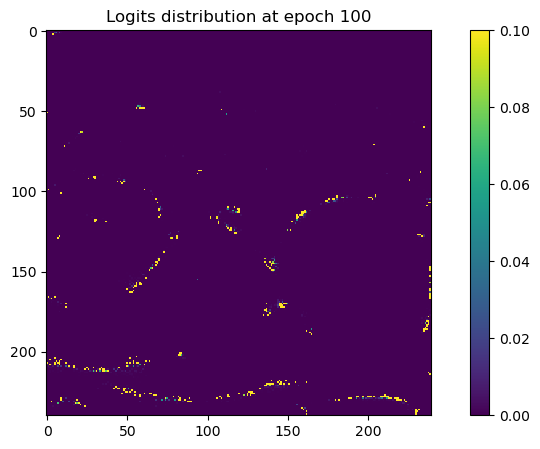

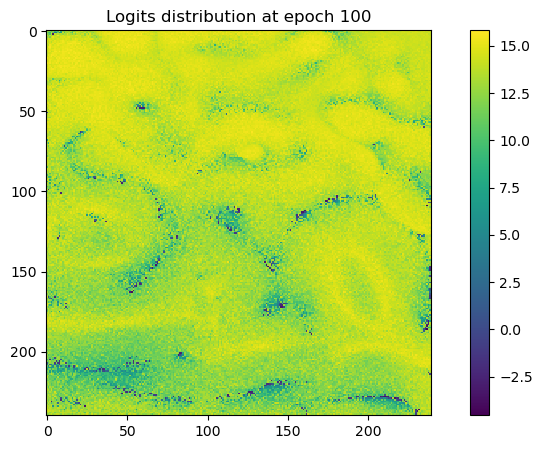

100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


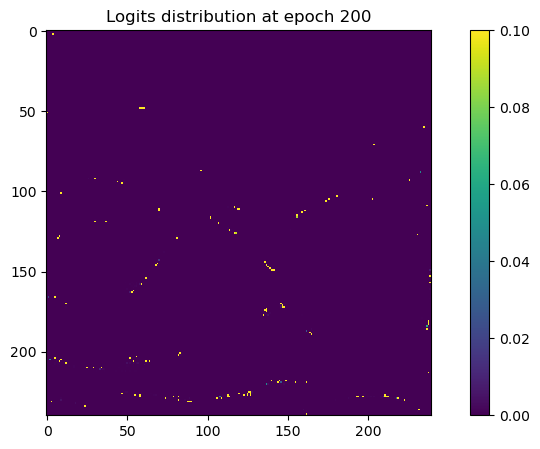

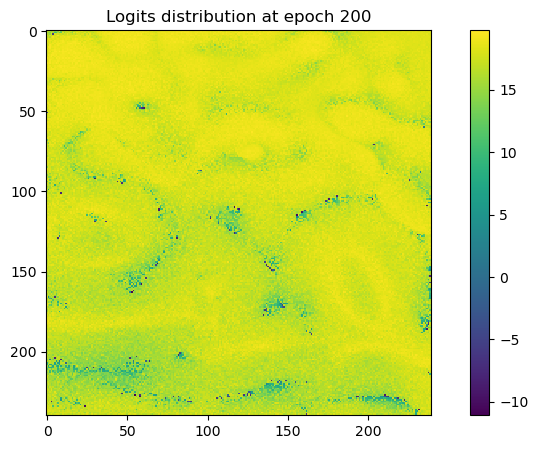

200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299


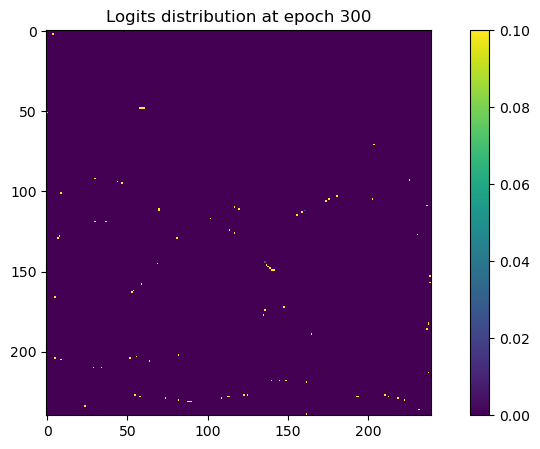

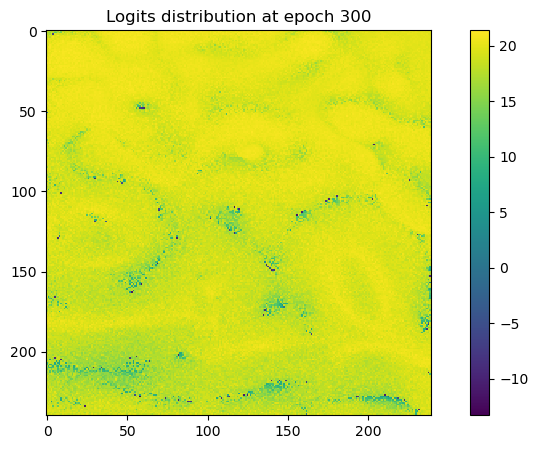

300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350
351
352
353
354
355
356
357
358
359
360
361
362
363
364
365
366
367
368
369
370
371
372
373
374
375
376
377
378
379
380
381
382
383
384
385
386
387
388
389
390
391
392
393
394
395
396
397
398
399


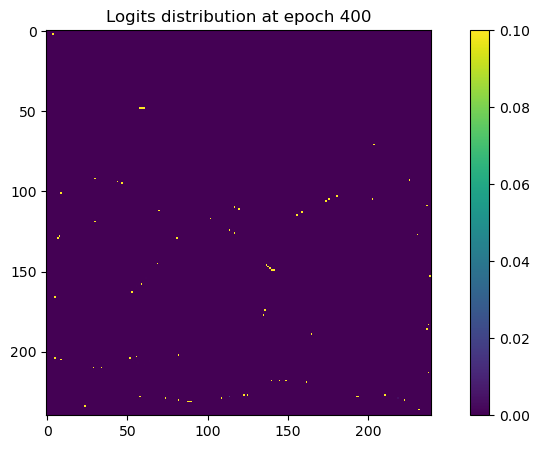

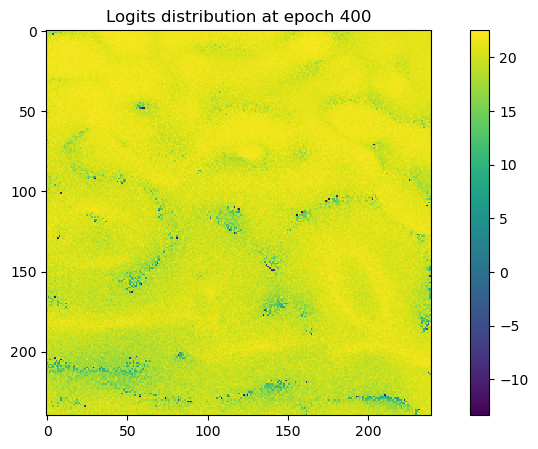

400
401
402
403
404
405
406
407
408
409
410
411
412
413
414
415
416
417
418
419
420
421
422
423
424
425
426
427
428
429
430
431
432
433
434
435
436
437
438
439
440
441
442
443
444
445
446
447
448
449
450
451
452
453
454
455
456
457
458
459
460
461
462
463
464
465
466
467
468
469
470
471
472
473
474
475
476
477
478
479
480
481
482
483
484
485
486
487
488
489
490
491
492
493
494
495
496
497
498
499


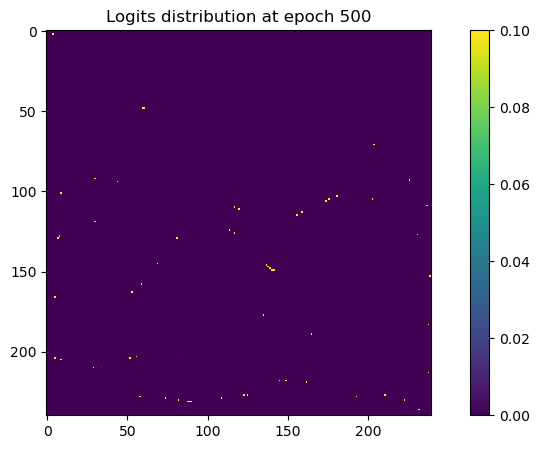

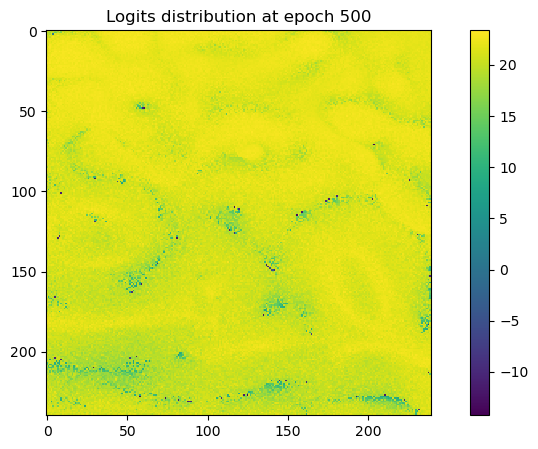

500
501
502
503
504
505
506
507
508
509
510
511
512
513
514
515
516
517
518
519
520
521
522
523
524
525
526
527
528
529
530
531
532
533
534
535
536
537
538
539
540
541
542
543
544
545
546
547
548
549
550
551
552
553
554
555
556
557
558
559
560
561
562
563
564
565
566
567
568
569
570
571
572
573
574
575
576
577
578
579
580
581
582
583
584
585
586
587
588
589
590
591
592
593
594
595
596
597
598
599


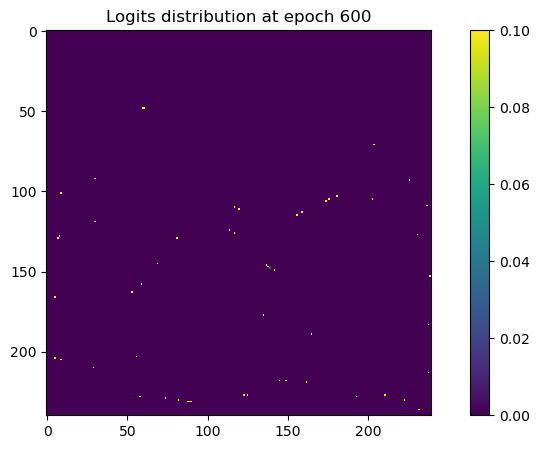

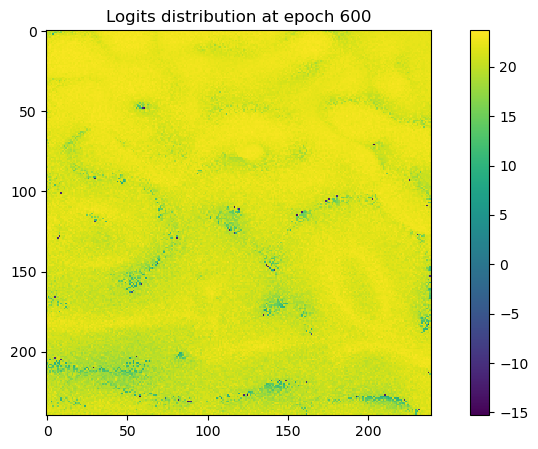

600
601
602
603
604
605
606
607
608
609
610
611
612
613
614
615
616
617
618
619
620
621
622
623
624
625
626
627
628
629
630
631
632
633
634
635
636
637
638
639
640
641
642
643
644
645
646
647
648
649
650
651
652
653
654
655
656
657
658
659
660
661
662
663
664
665
666
667
668
669
670
671
672
673
674
675
676
677
678
679
680
681
682
683
684
685
686
687
688
689
690
691
692
693
694
695
696
697
698
699


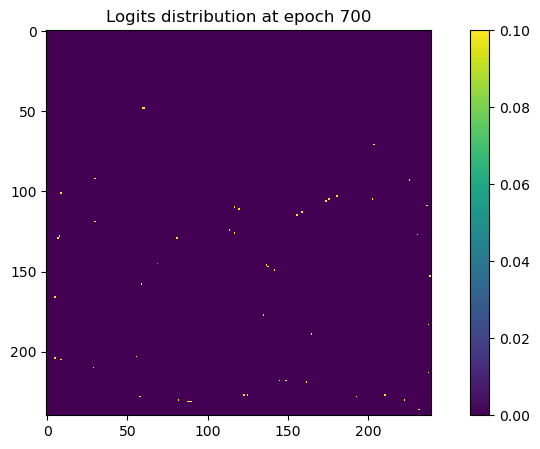

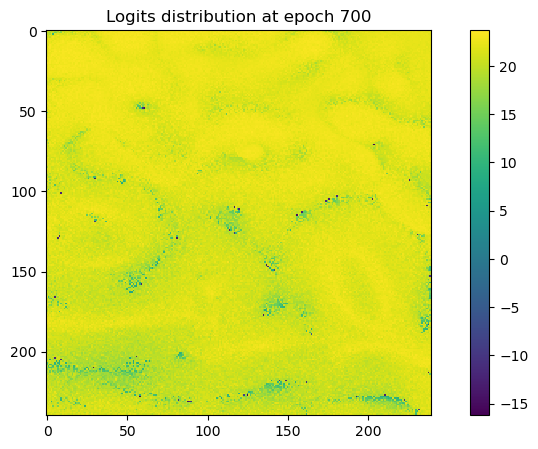

700
701
702
703
704
705
706
707
708
709
710
711
712
713
714
715
716
717
718
719
720
721
722
723
724
725
726
727
728
729
730
731
732
733
734
735
736
737
738
739
740
741
742
743
744
745
746
747
748
749
750
751
752
753
754
755
756
757
758
759
760
761
762
763
764
765
766
767
768
769
770
771
772
773
774
775
776
777
778
779
780
781
782
783
784
785
786
787
788
789
790
791
792
793
794
795
796
797
798
799


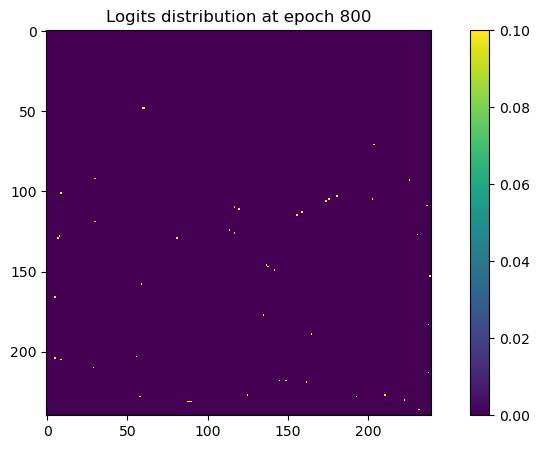

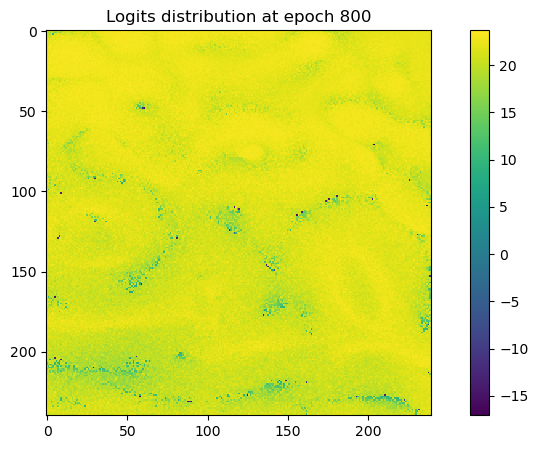

800
801
802
803
804
805
806
807
808
809
810
811
812
813
814
815
816
817
818
819
820
821
822
823
824
825
826
827
828
829
830
831
832
833
834
835
836
837
838
839
840
841
842
843
844
845
846
847
848
849
850
851
852
853
854
855
856
857
858
859
860
861
862
863
864
865
866
867
868
869
870
871
872
873
874
875
876
877
878
879
880
881
882
883
884
885
886
887
888
889
890
891
892
893
894
895
896
897
898
899


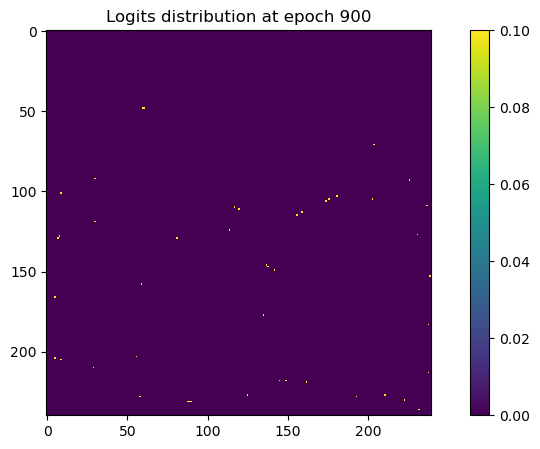

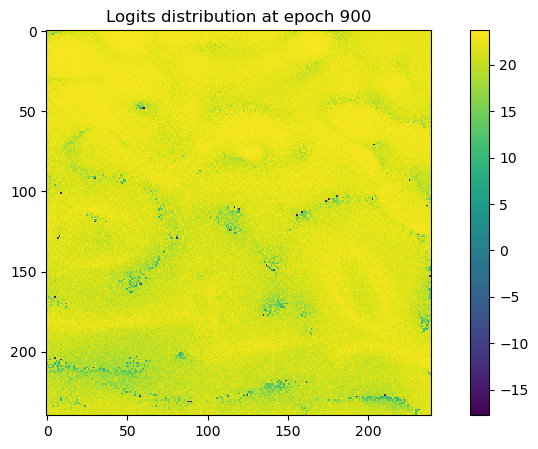

900
901
902
903
904
905
906
907
908
909
910
911
912
913
914
915
916
917
918
919
920
921
922
923
924
925
926
927
928
929
930
931
932
933
934
935
936
937
938
939
940
941
942
943
944
945
946
947
948
949
950
951
952
953
954
955
956
957
958
959
960
961
962
963
964
965
966
967
968
969
970
971
972
973
974
975
976
977
978
979
980
981
982
983
984
985
986
987
988
989
990
991
992
993
994
995
996
997
998
999


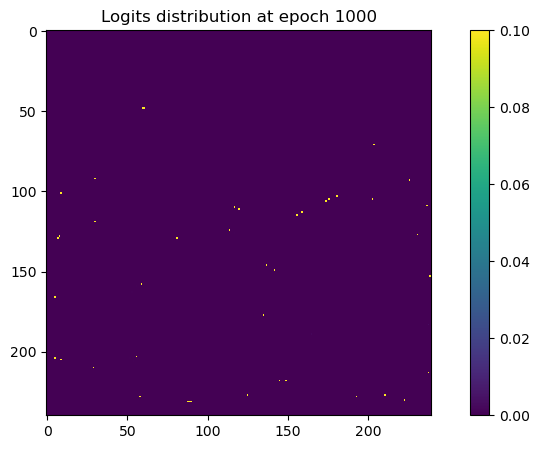

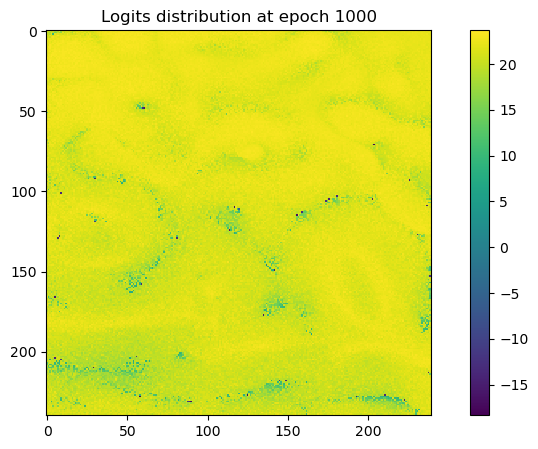

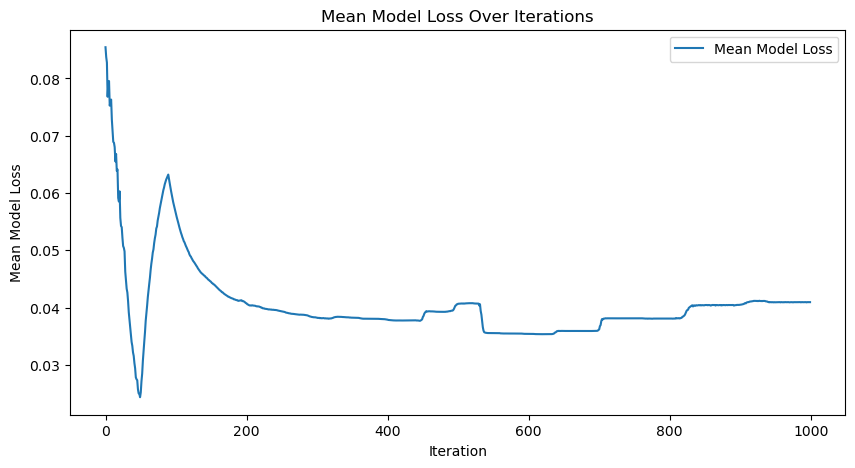

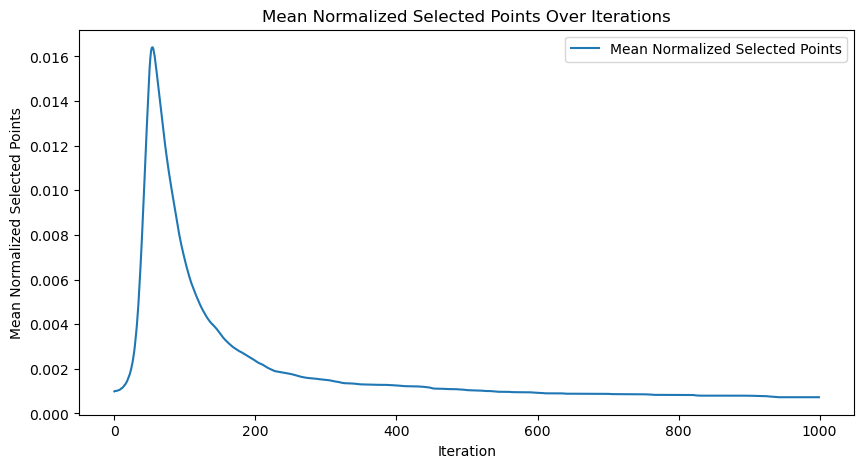

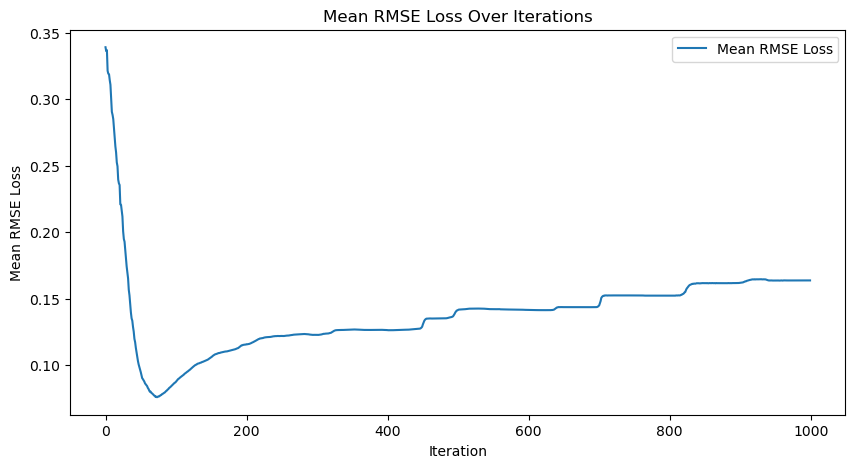

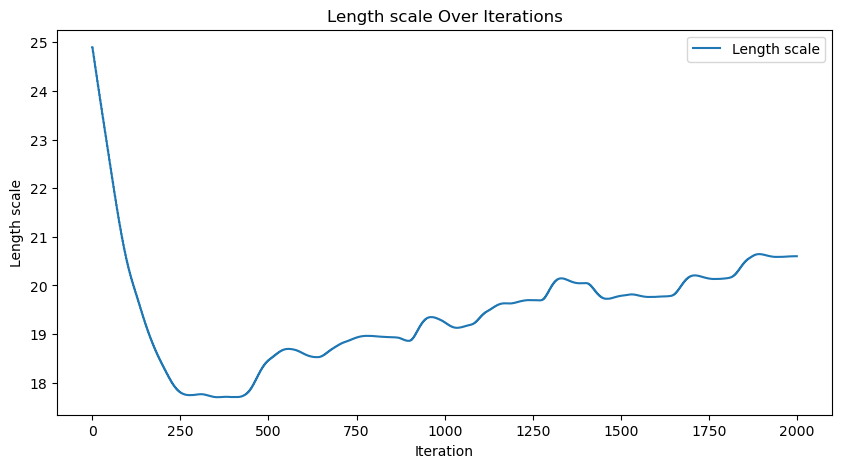

ValueError: different number of dimensions on data and dims: 1 vs 2

In [ ]:
print(f"Warped field shape: {warped_field.shape}")
# warped_field = warped_field.expand_dims(dim='time', axis=0)

inp_da_GS_warped = warped_field[:,border_size:-border_size, border_size:-border_size]

batch_size = warped_field.shape[0]
print(batch_size)
time = 1
lat = inp_da_GS_warped.shape[1]
lon = inp_da_GS_warped.shape[2]
inp_da_GS = inp_da.isel(lat=slice(crop_lat_start, crop_lat_end),
                     lon=slice(crop_lon_start, crop_lon_end))
n_draw = 15
n_iter = 1000
rate = 0.999
budget_obs = 1 - 0.999
accumulation_steps = 4

warmup_iterations = 50
delta_weight = 0.5
max_weight = 20.0
TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])
smoothness_weight = 0.0
# Initialize model
model_GS = GSModel_warped(time, lat, lon, rate, device).to(device)

inputs = []
targets = []

for j in range(batch_size):
    inp = torch.tensor(inp_da_GS_warped[j].values, device=device)
    # Prepare data
    mean_tgt = inp.mean().item()
    std_tgt = inp.std().item()

    tens_inp_da_warped = inp
    tens_inp_da_warped = (tens_inp_da_warped - mean_tgt) / std_tgt
    inp = inp_da_GS_warped[j]
    tens_inp_da_warped = tens_inp_da_warped.unsqueeze(0)
    tens_inp_da_warped.requires_grad_(True)
    
    inputs.append(tens_inp_da_warped)
    targets.append(tens_inp_da_warped)

# Stack inputs and targets to create a batch
inputs = torch.stack(inputs)
targets = torch.stack(targets)
batch = TrainingItem(input=inputs, tgt=targets)
print(batch.tgt.size())
start_temp = 5.0
min_temp = 0.1
alpha = 0.9
lr = 1e-1
temperature = start_temp
total_loss_list = []
mean_loss_list = []
mean_points_list = []
mean_mse_list = []
length_scale_list = []

decay_rate = (min_temp / start_temp) ** (1 / (n_iter - 1))

# Initialize optimizer
optimizer = optim.Adam(model_GS.parameters(), lr=lr)
scaler = GradScaler()

# Define pooling layer
pooling_layer = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

# Training loop
for k in range(n_iter):
    print(k)
    optimizer.zero_grad()
    total_points = 0
    total_mse = 0
    # weight = (1/1)*(k/n_iter)
    # Adjust weight based on the current iteration
    if k < warmup_iterations:
        weight = 0
    else:
        # Calculate weight incrementally after warmup
        weight = min((k - warmup_iterations + 1) * delta_weight, max_weight)
    for i in range(accumulation_steps):
        with autocast('cuda'):  # Mixed precision training
            mean_loss, normalized_selected_points, loss_mse, length_scale = model_GS(batch, budget_obs=budget_obs, tau=temperature, n_draw=n_draw, weight=weight)
            mean_loss = mean_loss / accumulation_steps  # Normalize loss by accumulation steps
            total_points += normalized_selected_points / accumulation_steps  # Accumulate normalized points
            total_mse += loss_mse / accumulation_steps  # Accumulate MSE loss
            penalty = downsampling_upsampling_loss(model_GS.logits, kernel_size=8, stride=1)
            total_loss = mean_loss + smoothness_weight * penalty
        scaler.scale(total_loss).backward()
    
    scaler.step(optimizer)
    scaler.update()
    total_loss_list.append(total_loss.item())
    mean_loss_list.append(mean_loss.item())
    mean_points_list.append(total_points.item())
    mean_mse_list.append(total_mse.item())
    temperature = start_temp * (min_temp / start_temp) ** (1 / (n_iter - 1))
    length_scale_list.append(length_scale.detach().cpu().numpy())

    if (k + 1) % 100 == 0:
        plt.figure(figsize=(10, 5))
        plt.title(f'Logits distribution at epoch {k + 1}')
        plt.imshow(1 - 1 / (1 + np.exp(-model_GS.logits[1, 0, :, :].detach().cpu().numpy())), cmap='viridis', interpolation='nearest', vmin=0, vmax=0.1)
        plt.colorbar()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.title(f'Logits distribution at epoch {k + 1}')
        plt.imshow(model_GS.logits[1, 0, :, :].detach().cpu().numpy(), cmap='viridis', interpolation='nearest')
        plt.colorbar()
        plt.show()
    #torch.cuda.empty_cache()
    length_scale_list.append(length_scale.detach().cpu().numpy())
    
# Plot mean loss
plt.figure(figsize=(10, 5))
plt.plot(mean_loss_list, label='Mean Model Loss')
plt.xlabel('Iteration')
plt.ylabel('Mean Model Loss')
plt.title('Mean Model Loss Over Iterations')
plt.legend()
plt.show()

# Plot mean normalized selected points
plt.figure(figsize=(10, 5))
plt.plot(mean_points_list, label='Mean Normalized Selected Points')
plt.xlabel('Iteration')
plt.ylabel('Mean Normalized Selected Points')
plt.title('Mean Normalized Selected Points Over Iterations')
plt.legend()
plt.show()

# Plot mean MSE loss
plt.figure(figsize=(10, 5))
plt.plot(mean_mse_list, label='Mean RMSE Loss')
plt.xlabel('Iteration')
plt.ylabel('Mean RMSE Loss')
plt.title('Mean RMSE Loss Over Iterations')
plt.legend()
plt.show()

# Plot mean MSE loss
plt.figure(figsize=(10, 5))
plt.plot(length_scale_list, label='Length scale')
plt.xlabel('Iteration')
plt.ylabel('Length scale')
plt.title('Length scale Over Iterations')
plt.legend()
plt.show()

# Visualization code (unchanged)
tensor_tgt = batch.tgt[0,0,0].detach().cpu().numpy()
da = xr.DataArray(tensor_tgt, dims=inp_da_GS_crop.dims, coords=inp_da_GS_crop.coords)
da = da * std_tgt + mean_tgt

plt.figure(figsize=(10, 5))
plt.title('Observation probability after training')
plt.imshow(1 - 1 / (1 + np.exp(-model_GS.logits[1, 0, :, :].detach().cpu().numpy())), cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar()
plt.show()

logits_init = (torch.zeros((2, time, lat, lon)))
logits_init.data[1, :, :, :] = np.log(rate / (1 - rate))
plt.figure(figsize=(10, 5))
plt.title('Observation probability before training')
plt.imshow(1 - 1 / (1 + np.exp(-logits_init[1, 0, :, :].detach().cpu().numpy())), cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.show()

plt.figure(figsize=(10, 5))
da.plot()
plt.title(f"Sample Values at Time Step {time_step_ssh}")
plt.show()

# Metrics

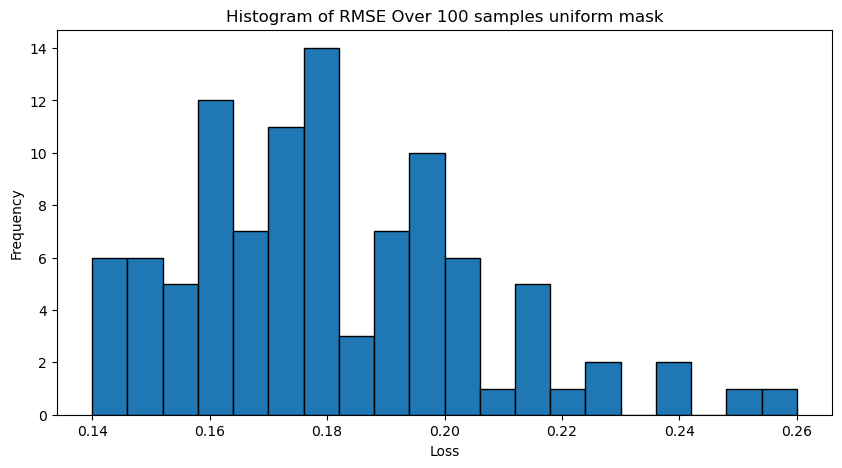

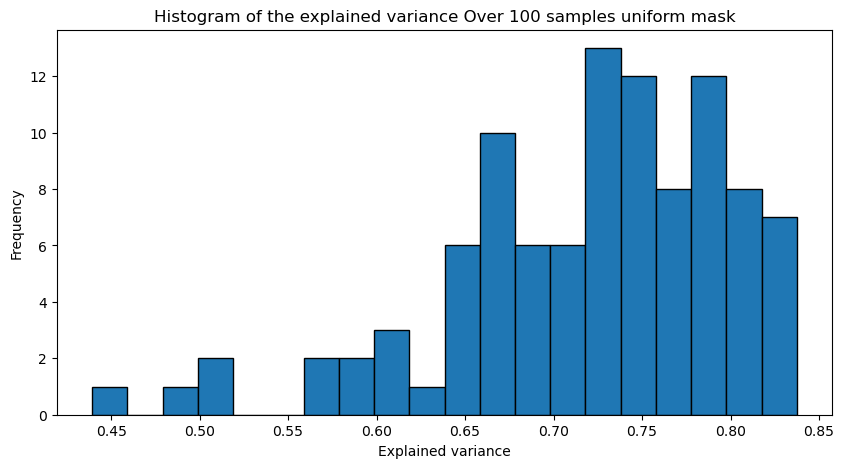

Mean Loss untrained: 0.18053171038627625
Normalized Selected Points: 0.0009027777705341578


In [ ]:
logits_inits_init = torch.zeros((2,1,lat,lon)).to(device)
logits_inits_init[1, :, :, :] = np.log(rate / (1 - rate))

tau = 1
hard = True 
padding_size = 10  # Adjust this value as needed
inp_da_GS = inp_da_GS_crop

mean_tgt = inp_da_GS.mean().item()
std_tgt = inp_da_GS.std().item()

tens_inp_da = torch.from_numpy(inp_da_GS.values).float().to(device)
tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da.requires_grad_(True)
time= 1
lat, lon =  inp_da_GS.shape
tgt_inp = tens_inp_da.clone()

losses_init = []
exp_var_init = []

for _ in range(100):
    gs_output = F.gumbel_softmax(logits_inits_init, hard=True, dim=0)[0, :, :, :]
    mask_input = gs_output.view(time,lat, lon)
    mask_input = mask_input.unsqueeze(0)  # Add batch dimension if necessary
    mask = mask_input
    selected_tgt_inp = tgt_inp * mask
    selected_tgt_inp[mask == 0] = float('nan')
    # Perform optimal interpolation
    output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_list[0])

    # Plot the output tensor
    output_numpy = output.detach().cpu().numpy()
    tgt_center_numpy = tgt_inp.detach().cpu().numpy()

    output_numpy_non = (output_numpy * std_tgt) + mean_tgt
    tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

    rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

    #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
    losses_init.append(rmse_loss)

    # Calculate variance of residuals and actual values
    residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
    actual_variance = np.var(tgt_center_non, ddof=1)

    # Explained Variance
    explained_variance = 1 - (residual_variance / actual_variance)
    exp_var_init.append(explained_variance)

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_init, bins=20, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_init, bins=20, edgecolor='black')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask')
plt.show()

# Print the mean of the losses
mean_loss_value_init = np.mean(losses_init)
print(f"Mean Loss untrained: {mean_loss_value_init}")

gs_output = F.gumbel_softmax(logits_inits_init, tau=tau, hard=hard, dim=0)[0, :, :, :]
mask_input = gs_output.view(time,lat, lon)
mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
normalized_selected_points = mask_input.mean()

valid_points_mask = ~torch.isnan(selected_tgt_inp)
print(f"Normalized Selected Points: {normalized_selected_points}")

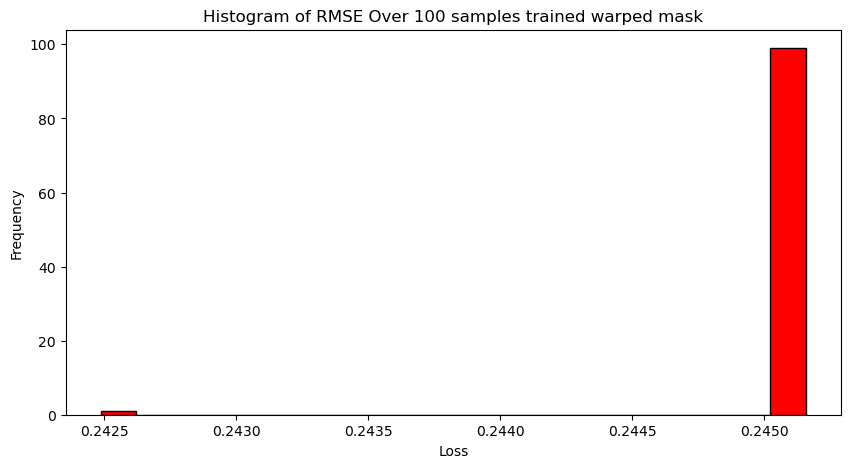

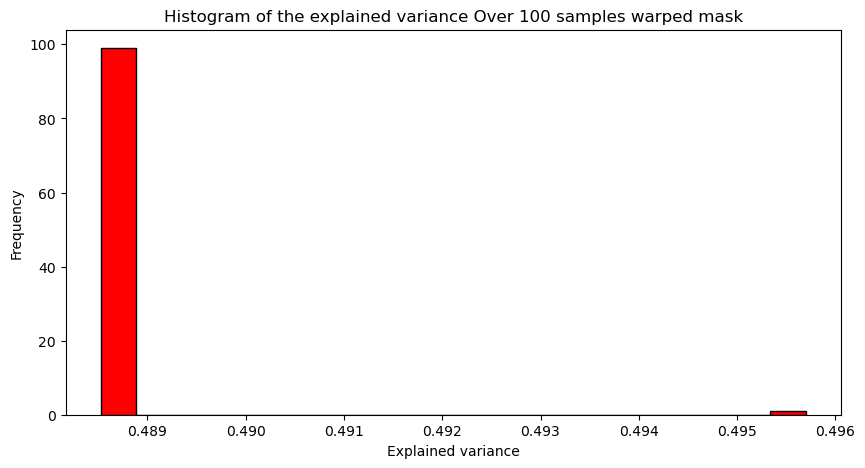

Mean Loss warped: 0.2451293170452118
Normalized Selected Points: 0.0007291666697710752


In [ ]:
logits = model_GS.logits

losses_trained = []
exp_var_trained = []
    
for _ in range(100):
    gs_output = F.gumbel_softmax(logits, hard=True, dim=0)[0, :, :, :]
    mask_input = gs_output.view(time,lat, lon)
    mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
    mask = mask_input
    selected_tgt_inp = tgt_inp * mask
    selected_tgt_inp[mask == 0] = float('nan')
    # Perform optimal interpolation
    output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_list[-1])

    # Plot the output tensor
    output_numpy = output.detach().cpu().numpy()
    tgt_center_numpy = batch.tgt.detach().cpu().numpy()

    output_numpy_non = (output_numpy * std_tgt) + mean_tgt
    tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

    rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

    #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
    losses_trained.append(rmse_loss)

    # Calculate variance of residuals and actual values
    residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
    actual_variance = np.var(tgt_center_non, ddof=1)

    # Explained Variance
    explained_variance = 1 - (residual_variance / actual_variance)
    exp_var_trained.append(explained_variance)


# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples trained warped mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_trained, bins=20, edgecolor='black', color='red')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples warped mask')
plt.show()

# Print the mean of the losses
mean_loss_value_trained= np.mean(losses_trained)
print(f"Mean Loss warped: {mean_loss_value_trained}")

# Generate mask using Gumbel-Softmax
gs_output_warped = F.gumbel_softmax(logits, tau=tau, hard=hard, dim=0)[0, :, :, :]
mask_input_warped = gs_output_warped.view(time,lat, lon)
mask_input_warped = mask_input_warped.unsqueeze(0)  # Add batch dimension if necessary
normalized_selected_points_warped = mask_input_warped.mean()
print(f"Normalized Selected Points: {normalized_selected_points_warped}")

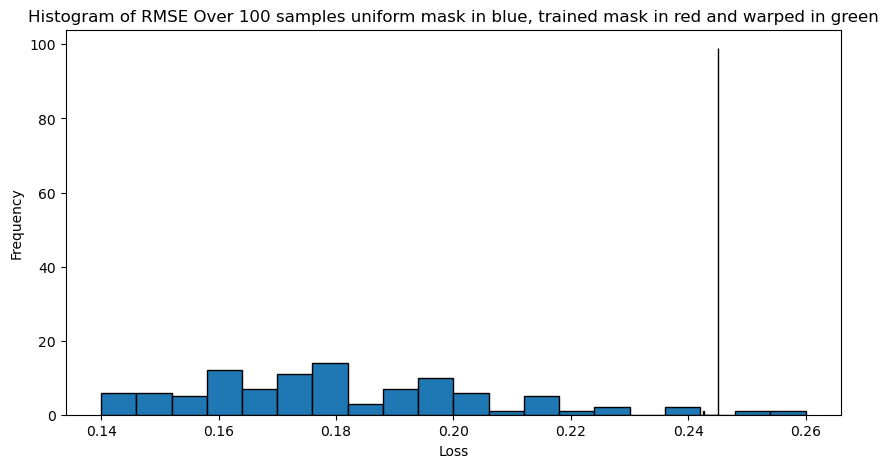

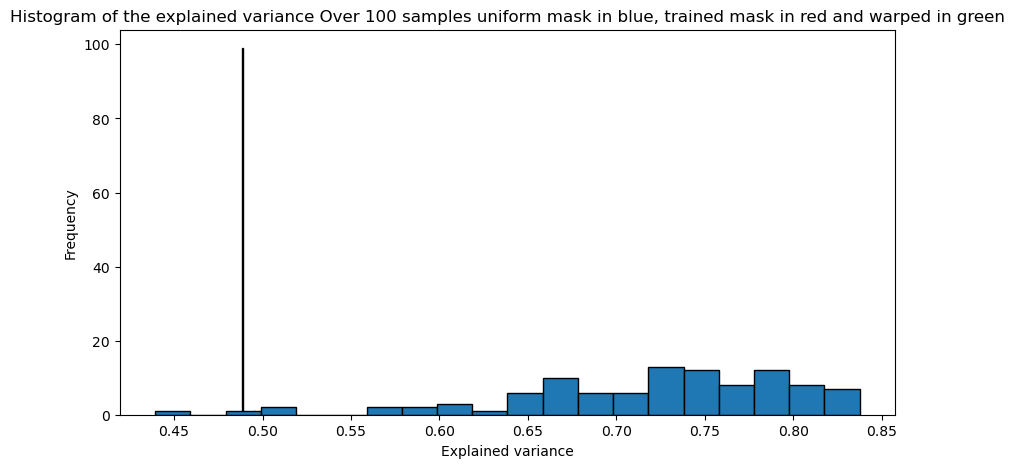

Percentage of uniform RMSE values worse than the trained mean RMSE: 2.00%
Percentage of uniform RMSE values better than the trained mean RMSE: 98.00%
Percentage of uniform explained variance values worse than the trained mean EV: 2.00%
Percentage of uniform explained variance values better than the trained mean EV: 98.00%


In [ ]:
# Plot histogram of the losses
plt.figure(figsize=(10, 5))
plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_init, bins=20, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask in blue, trained mask in red and warped in green')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
plt.hist(exp_var_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_init, bins=20, edgecolor='black')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask in blue, trained mask in red and warped in green')
plt.show()

# Count how many uniform samples have RMSE worse than the trained mean RMSE
worse_rmse_count = np.sum(np.array(losses_init) > mean_loss_value_trained)
better_rmse_count = np.sum(np.array(losses_init) < mean_loss_value_trained)
total_uniform_samples = len(losses_init)

percentage_worse_rmse = (worse_rmse_count / total_uniform_samples) * 100
percentage_better_rmse = (better_rmse_count / total_uniform_samples) * 100

print(f"Percentage of uniform RMSE values worse than the trained mean RMSE: {percentage_worse_rmse:.2f}%")
print(f"Percentage of uniform RMSE values better than the trained mean RMSE: {percentage_better_rmse:.2f}%")

# For explained variance, higher values are better.
mean_ev_trained = np.mean(exp_var_trained)
mean_ev_uniform = np.mean(exp_var_init)

# Count how many uniform samples have explained variance worse (i.e., lower) than the trained mean
worse_ev_count = np.sum(np.array(exp_var_init) < mean_ev_trained)
better_ev_count = np.sum(np.array(exp_var_init) > mean_ev_trained)
total_uniform_samples_ev = len(exp_var_init)

percentage_worse_ev = (worse_ev_count / total_uniform_samples_ev) * 100
percentage_better_ev = (better_ev_count / total_uniform_samples_ev) * 100

print(f"Percentage of uniform explained variance values worse than the trained mean EV: {percentage_worse_ev:.2f}%")
print(f"Percentage of uniform explained variance values better than the trained mean EV: {percentage_better_ev:.2f}%")

In [ ]:
from scipy.ndimage import maximum_filter, minimum_filter

def detect_local_maxima(field: np.ndarray, size: int = 3) -> np.ndarray:
    """
    Return a boolean mask of the same shape as `field` where True indicates a local maximum 
    within a `size x size` neighborhood.
    """
    neighborhood_max = maximum_filter(field, size=size)
    return (field == neighborhood_max)

def detect_local_minima(field: np.ndarray, size: int = 3) -> np.ndarray:
    """
    Return a boolean mask of the same shape as `field` where True indicates a local minimum 
    within a `size x size` neighborhood.
    """
    neighborhood_min = minimum_filter(field, size=size)
    return (field == neighborhood_min)

def gradient_magnitude(field: torch.Tensor) -> torch.Tensor:
    """
    Compute the 2D gradient magnitude of `field`, which is shape (H, W).
    Returns a tensor of shape (H, W) with sqrt((df/dx)^2 + (df/dy)^2).
    """
    # PyTorch >= 1.9 has torch.gradient; else, implement finite differences manually
    grad_y, grad_x = torch.gradient(field)  # dy, dx
    mag = torch.sqrt(grad_y**2 + grad_x**2)
    return mag

def pearson_correlation(x: torch.Tensor, y: torch.Tensor) -> float:
    """
    Compute Pearson correlation between two 2D or 1D tensors of the same shape.
    Returns a float in [-1, 1].
    """
    # Flatten
    xf = x.flatten().float()
    yf = y.flatten().float()

    # Convert to mean-centered
    xf_mean = xf.mean()
    yf_mean = yf.mean()
    num = torch.sum((xf - xf_mean) * (yf - yf_mean))
    den = torch.sqrt(torch.sum((xf - xf_mean)**2) * torch.sum((yf - yf_mean)**2))
    if den == 0:
        return 0.0
    corr = num / den
    return corr.item()

In [ ]:
selection_logit = model_GS.logits[1, 0]
mask_soft = torch.sigmoid(selection_logit) 
mask_hard = (mask_soft > 0.01).float()
field = batch.tgt[0,0, 0]
field_np = field.detach().cpu().numpy()
print(field.shape)
print(mask_hard.shape)
local_maxima = detect_local_maxima(field_np, size=3)  
local_minima = detect_local_minima(field_np, size=3)

field_grad = gradient_magnitude(field)  # returns a (lat, lon) torch.Tensor
field_grad_np = field_grad.detach().cpu().numpy()
grad_maxima = detect_local_maxima(field_grad_np, size=3)

local_maxima_t = torch.from_numpy(local_maxima.astype(np.float32)).to(device)
local_minima_t = torch.from_numpy(local_minima.astype(np.float32)).to(device)
grad_maxima_t  = torch.from_numpy(grad_maxima.astype(np.float32)).to(device)

corr_mask_maxima_field = pearson_correlation(mask_hard, local_maxima_t)
corr_mask_minima_field = pearson_correlation(mask_hard, local_minima_t)
corr_mask_gradmax_field = pearson_correlation(mask_hard, grad_maxima_t)


print("Correlation(Selected Mask, Field Local Maxima):", corr_mask_maxima_field)
print("Correlation(Selected Mask, Field Local Minima):", corr_mask_minima_field)
print("Correlation(Selected Mask, Gradient Field Maxima):", corr_mask_gradmax_field)


torch.Size([280, 280])
torch.Size([280, 280])
Correlation(Selected Mask, Field Local Maxima): 0.0011164312018081546
Correlation(Selected Mask, Field Local Minima): 0.0012200131313875318
Correlation(Selected Mask, Gradient Field Maxima): 0.002984513295814395
